# Milestone 1 — IPL Pressure & Performance Risk (2008–2024)

## Project Objective

In this project, I study how competitive pressure affects player performance in the IPL.

I define pressure using tournament stage:
- League matches  
- Playoffs  
- Final  

For comparison, I group playoffs and finals together as **high-pressure matches**, and treat league matches as lower-pressure matches.

My focus is not just on average performance, but on **performance risk and variability** under pressure.

I analyze two roles separately:
- Batting
- Bowling

All analysis is based strictly on structured cricket match data. I do not use psychological assumptions or external subjective data.

---

## Data Source

I use structured ball-by-ball IPL data from Cricsheet (2008–2024).  
The raw data is parsed and aggregated into player–match level records and stored in a SQLite database for reproducibility.

---

## What I Analyze

For batting, I focus on:
- Runs scored
- Strike rate
- Low-score indicator (runs < 10)
- Variability in runs across stages

For bowling, I focus on:
- Economy rate
- Wickets taken
- Runs conceded
- Variability across stages

---

## Machine Learning Extension

In the next stage of this project, I plan to build two predictive models:

### 1) Batting Model
Goal: Predict how many runs a specific player will score in a future match given similar match conditions.

Features I plan to use:
- Match stage (league / playoffs / final)
- Season
- Venue
- Player historical averages
- Player historical risk metrics (e.g., low-score rate)

Target variable:
- Runs scored

### 2) Bowling Model
Goal: Predict a bowler’s performance under similar match conditions.

Features I plan to use:
- Match stage
- Season
- Venue
- Historical economy
- Historical wicket rate

Target variable:
- Economy rate or wickets taken

The purpose of these models is not to guarantee predictions, but to estimate expected performance under similar pressure conditions.

---

This notebook covers:
- Problem formulation  
- Data acquisition  
- Database schema  
- Data exploration  
- Stage-aware performance comparison  

## Milestone 1 Deliverables Covered in This Notebook
- Problem formulation (inputs, outputs, time horizon)
- Data acquisition & documentation (source + local reproducibility)
- Data acquisition II (database schema + SQL storage)
- Data exploration (descriptive stats, plots, missingness, anomalies)
- Pressure tables (batting + bowling) and minimal plots
- Exports:
  - `schema.png`
  - `data_dictionary.pdf`
  - `requirements.txt`

In [36]:
!pip -q install pandas numpy matplotlib seaborn sqlalchemy graphviz reportlab
!apt-get -qq install graphviz

In [37]:
import os
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine, inspect

## 1) Problem Formulation

### Research Question

In this project, I study whether IPL players show higher performance risk and variability in pressure matches (playoffs and finals) compared to league matches.

In addition to descriptive analysis, I also build machine learning models to predict player performance under different match conditions.

My goal is not to predict match winners, but to understand and model how individual performance changes under pressure.

---

### Inputs

To answer this question and build predictive models, I use:

- Match stage (league, playoffs, final) as an objective proxy for pressure  
- Player role (batting or bowling)  
- Season  
- Venue  
- Historical player–match performance data  

For batting prediction models, I use:
- Player
- Stage (league / playoffs / final)
- Season
- Venue
- Balls faced (where applicable)

For bowling prediction models, I use:
- Bowler
- Stage
- Season
- Venue
- Overs bowled

---

### Outputs (Descriptive Metrics)

For batting, I measure:
- Average runs  
- Probability of low score (runs < 10)  
- Variance of runs  

For bowling, I measure:
- Average economy  
- Probability of high-cost spell  
- Variance of economy  
- Average wickets  

These help quantify performance risk and variability under pressure.

---

### Machine Learning Objective

Beyond descriptive statistics, I also build two predictive models:

Batting Model:
- Predict expected runs scored in a match given stage, season, venue, and player.

Bowling Model:
- Predict expected economy rate (or wickets) given stage, season, venue, and bowler.

These models allow me to estimate future performance under similar conditions, using only structured cricket data.

---

### Time Horizon

The dataset includes IPL match-level performance from 2008 to 2024.

All analysis and modeling are conducted at the player–match level, comparing league matches with high-pressure matches (playoffs and finals).

## 2) Data *Acquisition* (Sources and Relevance) bold text

### Primary Source
Cricsheet (https://cricsheet.org)

Cricsheet provides structured ball-by-ball cricket data. IPL coverage 2008–2024 enables reproducible aggregation to player–match outcomes.

### Local Reproducibility
This repository already contains processed outputs:
- `matches.csv`
- `players.csv`
- `player_match_batting.csv`
- `player_match_bowling.csv`
- `ipl_cricket_only.db` (SQLite integrated database)

The notebook verifies and uses these artifacts directly.

## 3) Load Data (CSV + SQLite)

We support two routes:
- **Preferred**: Read from existing SQLite database (`ipl_cricket_only.db`)
- Fallback: Read CSV files if needed

This supports reproducibility and aligns with Milestone 1 database requirements.

In [38]:
import sqlite3
import pandas as pd
from pathlib import Path

# Database path
DB_PATH = Path("/content/ipl_cricket_only.db")

# Check if file exists
if not DB_PATH.exists():
    raise FileNotFoundError(f"Database file not found: {DB_PATH}")

print("Database found at:", DB_PATH)

# Connect to SQLite
con = sqlite3.connect(DB_PATH)

# List tables
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    con
)
print("Tables:", tables["name"].tolist())

# Load tables
matches = pd.read_sql_query("SELECT * FROM matches;", con)
players = pd.read_sql_query("SELECT * FROM players;", con)
batting = pd.read_sql_query("SELECT * FROM player_match_batting;", con)
bowling = pd.read_sql_query("SELECT * FROM player_match_bowling;", con)

con.close()

print("\nLoaded shapes:")
print("matches :", matches.shape)
print("players :", players.shape)
print("batting :", batting.shape)
print("bowling :", bowling.shape)

Database found at: /content/ipl_cricket_only.db
Tables: ['matches', 'players', 'player_match_batting', 'player_match_bowling']

Loaded shapes:
matches : (1095, 21)
players : (732, 1)
batting : (16515, 11)
bowling : (12978, 17)


In [39]:

matches.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [40]:
players.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   player_name  732 non-null    object
dtypes: object(1)
memory usage: 5.8+ KB


In [41]:
batting.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16515 entries, 0 to 16514
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   match_id      16515 non-null  int64  
 1   player        16515 non-null  object 
 2   runs          16515 non-null  int64  
 3   balls         16515 non-null  int64  
 4   strike_rate   16515 non-null  float64
 5   low_score     16515 non-null  int64  
 6   season        16515 non-null  object 
 7   date          16515 non-null  object 
 8   venue         16515 non-null  object 
 9   match_type    16515 non-null  object 
 10  stage_bucket  16515 non-null  object 
dtypes: float64(1), int64(4), object(6)
memory usage: 1.4+ MB


In [42]:

bowling.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12978 entries, 0 to 12977
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   match_id                      12978 non-null  int64  
 1   bowler                        12978 non-null  object 
 2   balls                         12978 non-null  int64  
 3   runs_conceded                 12978 non-null  int64  
 4   wides                         12978 non-null  int64  
 5   no_balls                      12978 non-null  int64  
 6   wickets                       12978 non-null  int64  
 7   dot_balls                     12978 non-null  int64  
 8   overs                         12978 non-null  float64
 9   economy                       12978 non-null  float64
 10  strike_rate_balls_per_wicket  7778 non-null   float64
 11  dot_ball_rate                 12978 non-null  float64
 12  season                        12978 non-null  object 
 13  d

In [43]:

matches.describe()


,id,result_margin,target_runs,target_overs
count,1.095000e+03,1076.000000,1092.000000,1092.000000
mean,9.048283e+05,17.259294,165.684066,19.759341
std,3.677402e+05,21.787444,33.427048,1.581108
min,3.359820e+05,1.000000,43.000000,5.000000
25%,5.483315e+05,6.000000,146.000000,20.000000
50%,9.809610e+05,8.000000,166.000000,20.000000
75%,1.254062e+06,20.000000,187.000000,20.000000
max,1.426312e+06,146.000000,288.000000,20.000000


In [44]:
batting.describe()


,match_id,runs,balls,strike_rate,low_score
count,1.651500e+04,16515.000000,16515.000000,16515.000000,16515.000000
mean,9.078626e+05,19.985710,15.798971,109.237847,0.424463
std,3.696686e+05,21.360857,13.934583,66.104126,0.494276
min,3.359820e+05,0.000000,1.000000,0.000000,0.000000
25%,5.483310e+05,4.000000,5.000000,66.666667,0.000000
50%,9.809710e+05,13.000000,11.000000,107.692308,0.000000
75%,1.254071e+06,29.000000,23.000000,146.153846,1.000000
max,1.426312e+06,175.000000,77.000000,600.000000,1.000000


In [45]:
bowling.describe()

,match_id,balls,runs_conceded,wides,no_balls,wickets,dot_balls,overs,economy,strike_rate_balls_per_wicket,dot_ball_rate
count,1.297800e+04,12978.000000,12978.000000,12978.0,12978.0,12978.000000,12978.000000,12978.000000,12978.000000,7778.000000,12978.000000
mean,9.030483e+05,20.104793,26.795808,0.0,0.0,0.997843,6.968562,3.350799,8.284134,16.229303,0.335683
std,3.688445e+05,6.432664,11.063245,0.0,0.0,1.059090,3.730573,1.072111,3.025116,7.066250,0.144230
min,3.359820e+05,1.000000,0.000000,0.0,0.0,0.000000,0.000000,0.166667,0.000000,1.000000,0.000000
25%,5.483270e+05,18.000000,19.000000,0.0,0.0,0.000000,4.000000,3.000000,6.240000,12.000000,0.240000
50%,9.809590e+05,24.000000,26.000000,0.0,0.0,1.000000,7.000000,4.000000,8.000000,13.000000,0.333333
75%,1.254063e+06,25.000000,34.000000,0.0,0.0,2.000000,10.000000,4.166667,10.000000,24.000000,0.423077
max,1.426312e+06,34.000000,73.000000,0.0,0.0,6.000000,19.000000,5.666667,36.000000,32.000000,1.000000


In [46]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,...,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2,stage_bucket
0,335982,2007/08,Bangalore,2008-04-18 00:00:00,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,...,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,None,Asad Rauf,RE Koertzen,league
1,335983,2007/08,Chandigarh,2008-04-19 00:00:00,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,...,Chennai Super Kings,runs,33.0,241.0,20.0,N,None,MR Benson,SL Shastri,league
2,335984,2007/08,Delhi,2008-04-19 00:00:00,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,...,Delhi Daredevils,wickets,9.0,130.0,20.0,N,None,Aleem Dar,GA Pratapkumar,league
3,335985,2007/08,Mumbai,2008-04-20 00:00:00,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,...,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,None,SJ Davis,DJ Harper,league
4,335986,2007/08,Kolkata,2008-04-20 00:00:00,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,...,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,None,BF Bowden,K Hariharan,league


In [47]:
players.head()

,player_name
0,A Ashish Reddy
1,A Badoni
2,A Chandila
3,A Chopra
4,A Choudhary


In [48]:
batting.head()

,match_id,player,runs,balls,strike_rate,low_score,season,date,venue,match_type,stage_bucket
0,335982,AA Noffke,9,12,75.000000,1,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
1,335982,B Akhil,0,2,0.000000,1,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
2,335982,BB McCullum,158,77,205.194805,0,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
3,335982,CL White,6,10,60.000000,1,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
4,335982,DJ Hussey,12,12,100.000000,0,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league


In [49]:
bowling.head()

,match_id,bowler,balls,runs_conceded,wides,no_balls,wickets,dot_balls,overs,economy,strike_rate_balls_per_wicket,dot_ball_rate,season,date,venue,match_type,stage_bucket
0,335982,AA Noffke,25,41,0,0,1,6,4.166667,9.840000,25.000000,0.240000,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
1,335982,AB Agarkar,28,25,0,0,3,15,4.666667,5.357143,9.333333,0.535714,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
2,335982,AB Dinda,20,9,0,0,2,11,3.333333,2.700000,10.000000,0.550000,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
3,335982,CL White,7,24,0,0,0,0,1.166667,20.571429,NaN,0.000000,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league
4,335982,I Sharma,19,13,0,0,1,10,3.166667,4.105263,19.000000,0.526316,2007/08,2008-04-18 00:00:00,M Chinnaswamy Stadium,League,league


## 4) Database Schema Verification (Data Acquisition II)

We inspect the schema using SQLite metadata:
- table names
- column names
- basic join keys (`match_id`, player fields)

In [50]:
con = sqlite3.connect(DB_PATH)

def pragma_info(table):
    return pd.read_sql_query(f"PRAGMA table_info({table});", con)

for t in ["matches", "players", "player_match_batting", "player_match_bowling"]:
    print("\n====================")
    print("TABLE:", t)
    display(pragma_info(t))

con.close()


TABLE: matches


,cid,name,type,notnull,dflt_value,pk
0,0,id,INTEGER,0,None,0
1,1,season,TEXT,0,None,0
2,2,city,TEXT,0,None,0
3,3,date,TIMESTAMP,0,None,0
4,4,match_type,TEXT,0,None,0
5,5,player_of_match,TEXT,0,None,0
6,6,venue,TEXT,0,None,0
7,7,team1,TEXT,0,None,0
8,8,team2,TEXT,0,None,0
9,9,toss_winner,TEXT,0,None,0



TABLE: players


,cid,name,type,notnull,dflt_value,pk
0,0,player_name,TEXT,0,None,0



TABLE: player_match_batting


,cid,name,type,notnull,dflt_value,pk
0,0,match_id,INTEGER,0,None,0
1,1,player,TEXT,0,None,0
2,2,runs,INTEGER,0,None,0
3,3,balls,INTEGER,0,None,0
4,4,strike_rate,REAL,0,None,0
5,5,low_score,INTEGER,0,None,0
6,6,season,TEXT,0,None,0
7,7,date,TIMESTAMP,0,None,0
8,8,venue,TEXT,0,None,0
9,9,match_type,TEXT,0,None,0



TABLE: player_match_bowling


,cid,name,type,notnull,dflt_value,pk
0,0,match_id,INTEGER,0,None,0
1,1,bowler,TEXT,0,None,0
2,2,balls,INTEGER,0,None,0
3,3,runs_conceded,INTEGER,0,None,0
4,4,wides,INTEGER,0,None,0
5,5,no_balls,INTEGER,0,None,0
6,6,wickets,INTEGER,0,None,0
7,7,dot_balls,INTEGER,0,None,0
8,8,overs,REAL,0,None,0
9,9,economy,REAL,0,None,0


## 5) Stage Buckets and 3-Stage Grouping

The database includes:
- `stage_bucket` in `matches`
- and also embedded in the `player_match_batting` and `player_match_bowling` tables.

For this project, we keep match stages **separate**:

- **league**
- **playoffs**
- **final**

This preserves tournament structure and supports clearer comparisons between normal-season matches and elimination matches.

Any other categories (if present) are excluded from analysis comparisons.

In [51]:
import numpy as np

def normalize_stage_bucket(s):
    """
    Map raw stage labels to one of:
    - league
    - playoffs
    - final

    Any unknown/unmapped labels return 'other' and will be excluded from comparisons.
    """
    if pd.isna(s):
        return np.nan
    x = str(s).strip().lower()

    # League
    if "league" in x:
        return "league"
    # We check final before playoffs to avoid incorrectly mapping "final" into playoffs.
    if "final" in x:
        return "final"

    # Playoffs (qualifiers/eliminators, etc.)
    if "playoff" in x or "qualifier" in x or "eliminator" in x:
        return "playoffs"

    return "other"

# Apply to batting and bowling (they contain stage_bucket already)
if "stage_bucket" not in batting.columns:
    raise ValueError("batting table missing stage_bucket")
if "stage_bucket" not in bowling.columns:
    raise ValueError("bowling table missing stage_bucket")

batting["stage_bucket_3"] = batting["stage_bucket"].apply(normalize_stage_bucket)
bowling["stage_bucket_3"] = bowling["stage_bucket"].apply(normalize_stage_bucket)

print("Batting stage_bucket_3 counts:")
display(batting["stage_bucket_3"].value_counts(dropna=False))

print("Bowling stage_bucket_3 counts:")
display(bowling["stage_bucket_3"].value_counts(dropna=False))

# Keep only the three stages for analysis
VALID_STAGES = ["league", "playoffs", "final"]

bat_3 = batting[batting["stage_bucket_3"].isin(VALID_STAGES)].copy()
bowl_3 = bowling[bowling["stage_bucket_3"].isin(VALID_STAGES)].copy()

print("Filtered batting shape:", bat_3.shape)
print("Filtered bowling shape:", bowl_3.shape)

Batting stage_bucket_3 counts:


,count
stage_bucket_3,
league,15511
playoffs,739
final,265


Bowling stage_bucket_3 counts:


,count
stage_bucket_3,
league,12256
playoffs,527
final,195


Filtered batting shape: (16515, 12)
Filtered bowling shape: (12978, 18)


## 6) Data Exploration — Missingness and Basic Health Checks

Milestone 1 requires documenting:
- missing values
- anomalies or behaviors needing future attention
- basic dataset health checks

We compute missingness rates for each table and note columns with substantial missing values.

## Data Exploration — Part II: Issue Identification

In this section, we document potential data issues that could affect downstream analysis.
The goal is to identify and record these issues, not to resolve them at this stage.

### Duplicates and Record Uniqueness

No exact duplicate player–match records were observed.
Although no explicit primary key is defined in SQLite, records are effectively unique by:
- (match_id, player) for batting
- (match_id, bowler) for bowling

In [52]:
def missing_report(df, name, top=15):
    rep = (df.isna().mean() * 100).sort_values(ascending=False).head(top)
    print(f"\n{name} — Top Missingness (%)")
    display(rep.to_frame("missing_%"))

missing_report(matches, "matches")
missing_report(players, "players")
missing_report(bat_3, "batting (filtered to league/playoffs/final)")
missing_report(bowl_3, "bowling (filtered to league/playoffs/final)")


matches — Top Missingness (%)


,missing_%
method,98.082192
city,4.657534
result_margin,1.735160
winner,0.456621
player_of_match,0.456621
target_runs,0.273973
target_overs,0.273973
season,0.000000
id,0.000000
match_type,0.000000



players — Top Missingness (%)


,missing_%
player_name,0.0



batting (filtered to league/playoffs/final) — Top Missingness (%)


,missing_%
match_id,0.0
player,0.0
runs,0.0
balls,0.0
strike_rate,0.0
low_score,0.0
season,0.0
date,0.0
venue,0.0
match_type,0.0



bowling (filtered to league/playoffs/final) — Top Missingness (%)


,missing_%
strike_rate_balls_per_wicket,40.067807
match_id,0.000000
bowler,0.000000
balls,0.000000
wides,0.000000
runs_conceded,0.000000
wickets,0.000000
dot_balls,0.000000
overs,0.000000
no_balls,0.000000


In [53]:
# Check for duplicate player–match records
dup_bat = bat_3.duplicated(subset=["match_id", "player"]).sum()
dup_bowl = bowl_3.duplicated(subset=["match_id", "bowler"]).sum()

print("Duplicate batting rows (match_id, player):", dup_bat)
print("Duplicate bowling rows (match_id, bowler):", dup_bowl)

Duplicate batting rows (match_id, player): 0
Duplicate bowling rows (match_id, bowler): 0


### Missing Values

Missing values primarily reflect non-participation rather than data quality issues.
For example, bowlers who did not take wickets have undefined bowling strike rates.
These patterns are structural and expected given cricket match rules.

In [54]:
missing_report(matches, "matches")
missing_report(players, "players")
missing_report(bat_3, "batting (filtered to league/playoffs/final)")
missing_report(bowl_3, "bowling (filtered to league/playoffs/final)")


matches — Top Missingness (%)


,missing_%
method,98.082192
city,4.657534
result_margin,1.735160
winner,0.456621
player_of_match,0.456621
target_runs,0.273973
target_overs,0.273973
season,0.000000
id,0.000000
match_type,0.000000



players — Top Missingness (%)


,missing_%
player_name,0.0



batting (filtered to league/playoffs/final) — Top Missingness (%)


,missing_%
match_id,0.0
player,0.0
runs,0.0
balls,0.0
strike_rate,0.0
low_score,0.0
season,0.0
date,0.0
venue,0.0
match_type,0.0



bowling (filtered to league/playoffs/final) — Top Missingness (%)


,missing_%
strike_rate_balls_per_wicket,40.067807
match_id,0.000000
bowler,0.000000
balls,0.000000
wides,0.000000
runs_conceded,0.000000
wickets,0.000000
dot_balls,0.000000
overs,0.000000
no_balls,0.000000


In [55]:
# How many unique seasons?
matches["season"].nunique()

17

In [56]:
matches["season"].min(), matches["season"].max()

('2007/08', '2024')

### Standardization Issues

Match stages were standardized using the `stage_bucket` variable into league, playoffs, and final.
No inconsistent or unexpected stage labels were observed after filtering.

In [57]:
print("Batting stage distribution:")
display(bat_3["stage_bucket"].value_counts(dropna=False))

print("Bowling stage distribution:")
display(bowl_3["stage_bucket"].value_counts(dropna=False))

Batting stage distribution:


,count
stage_bucket,
league,15511
playoffs,739
final,265


Bowling stage distribution:


,count
stage_bucket,
league,12256
playoffs,527
final,195


### Noise vs Outliers

Extreme performances were retained as meaningful observations rather than removed as outliers.
Because the project focuses on performance risk and variability, such extremes are treated as signal rather than noise.
Final matches are relatively rare, and this imbalance is documented rather than corrected at this stage.

### Open Questions for Stakeholders

- Should abandoned or no-result matches be excluded from risk calculations?
- Is the current stage_bucket mapping for qualifiers and eliminators appropriate?
- Should minimum appearance thresholds be enforced separately for finals due to small sample size?
- Are super-over performances included, and should they be treated differently?

EDA — Descriptive Statistics by Match Stage (3-way)

We summarize performance separately for:
- league
- playoffs
- final

This provides an interpretable baseline view of how distributions may shift as tournament pressure increases.

These are descriptive comparisons only (Milestone 1 does not require modeling).

In [58]:
# Batting 3-stage summary
bat_summary_3 = bat_3.groupby("stage_bucket_3").agg(
    n_innings=("runs", "size"),
    avg_runs=("runs", "mean"),
    std_runs=("runs", "std"),
    p10_runs=("runs", lambda x: np.nanpercentile(x, 10)),
    p50_runs=("runs", lambda x: np.nanpercentile(x, 50)),
    p90_runs=("runs", lambda x: np.nanpercentile(x, 90)),
).reset_index().sort_values("stage_bucket_3")

# Bowling 3-stage summary
bowl_summary_3 = bowl_3.groupby("stage_bucket_3").agg(
    n_spells=("match_id", "size"),
    avg_economy=("economy", "mean"),
    std_economy=("economy", "std"),
    avg_wickets=("wickets", "mean"),
    p90_economy=("economy", lambda x: np.nanpercentile(x, 90)),
).reset_index().sort_values("stage_bucket_3")

print("Batting summary (league / playoffs / final):")
display(bat_summary_3)

print("Bowling summary (league / playoffs / final):")
display(bowl_summary_3)

Batting summary (league / playoffs / final):


,stage_bucket_3,n_innings,avg_runs,std_runs,p10_runs,p50_runs,p90_runs
0,final,265,19.962264,22.760747,0.4,11.0,52.6
1,league,15511,20.067114,21.387845,1.0,13.0,51.0
2,playoffs,739,18.285521,20.202657,0.0,11.0,45.0


Bowling summary (league / playoffs / final):


,stage_bucket_3,n_spells,avg_economy,std_economy,avg_wickets,p90_economy
0,final,195,8.339951,2.685622,1.087179,12.000000
1,league,12256,8.298180,3.034073,0.990780,12.000000
2,playoffs,527,7.936821,2.917218,1.129032,11.472727


### Important : Features Used for Analysis and Modeling

From this point forward, I restrict the dataset to only the variables that are directly relevant to my research question and future machine learning models.

I intentionally remove all unused columns to keep the notebook clean, interpretable, and reproducible.

---

### Batting Features (player_match_batting)

These variables are used for descriptive analysis and for the future batting prediction model:

- `player` — Player name (identifier)
- `runs` — Runs scored (target variable for ML)
- `balls` — Balls faced
- `strike_rate` — Runs per 100 balls
- `low_score` — Indicator (1 if runs < 10)
- `stage_bucket` — league / playoffs / final (pressure proxy)
- `season` — IPL season
- `venue` — Match venue

For the ML model:
- Target variable: `runs`
- Input features: `balls`, `strike_rate`, `stage_bucket`, `season`, `venue`

---

### Bowling Features (player_match_bowling)

These variables are used for descriptive analysis and for the future bowling prediction model:

- `bowler` — Bowler name (identifier)
- `economy` — Runs conceded per over (target variable for ML)
- `wickets` — Wickets taken
- `runs_conceded` — Total runs conceded
- `stage_bucket` — league / playoffs / final (pressure proxy)
- `season` — IPL season
- `venue` — Match venue

For the ML model:
- Target variable: `economy`
- Input features: `wickets`, `runs_conceded`, `stage_bucket`, `season`, `venue`

---

### Why These Features?

These features directly capture:
- Player performance
- Match pressure (via stage_bucket)
- Contextual variation (season and venue)

I avoid including unnecessary metadata (e.g., umpire names, toss information, city, etc.) because they are not required for my research objective or prediction task.

This ensures the notebook remains simple, focused, and aligned with the problem formulation.

## Batting Risk Summary by Match Stage (League vs Playoffs vs Final)

In this step, I build a player-level batting summary to compare performance across the three IPL stages:

- **league**
- **playoffs**
- **final**

### What I do here

1. **Create a low-score indicator**
   - I mark an innings as a low score if `runs < 10`.

2. **Aggregate performance by player and stage**
   For each player in each stage, I compute:
   - `n` = number of innings
   - `avg_runs` = average runs
   - `p_low` = low-score rate
   - `var_runs` = variability in runs (variance)

3. **Reshape to one row per player**
   I pivot the table so that each player has separate columns for league, playoffs, and final metrics.

4. **Filter for enough data**
   To avoid unreliable comparisons, I only keep players who have:
   - at least `MIN_INNINGS` innings in **league**, and
   - at least `MIN_INNINGS` innings in **playoffs or final**

5. **Compute stage differences (deltas) vs league**
   I calculate how each player changes in playoffs/finals compared to their league baseline:
   - change in low-score probability
   - change in average runs

6. **Create a pressure impact index**
   I summarize “worse under pressure” using an index where higher is worse:
   - increased low-score rate is bad
   - decreased average runs is bad (scaled by league average)

7. **Assign simple labels**
   Each player gets a label for playoffs and finals:
   - **Stable**
   - **More risky under pressure**
   - **High pressure drop**
   - (or **Insufficient data** if not enough matches)

The final output is `batting_3stage_table`, which I use later for ranking players and making pressure-related plots.

In [59]:
MIN_INNINGS = 5
LOW_RUNS_THRESHOLD = 10

# Ensure expected columns
if "runs" not in bat_3.columns:
    raise ValueError("Expected column 'runs' not found in bat_3")
if "player" not in bat_3.columns:
    raise ValueError("Expected column 'player' not found in bat_3")

# Risk indicator
bat_3["low_score"] = (bat_3["runs"] < LOW_RUNS_THRESHOLD).astype(int)

# Aggregate: player × stage
bat_stage = (
    bat_3.groupby(["player", "stage_bucket_3"])
        .agg(
            n=("runs", "size"),
            avg_runs=("runs", "mean"),
            p_low=("low_score", "mean"),
            var_runs=("runs", "var")
        )
        .reset_index()
)

# Pivot to wide: one row per player
bat_wide = bat_stage.pivot(index="player", columns="stage_bucket_3", values=["n","avg_runs","p_low","var_runs"])
bat_wide.columns = [f"{m}_{s}" for m, s in bat_wide.columns]
bat_wide = bat_wide.reset_index()

# Keep players with enough league innings, and at least MIN in playoffs OR final for comparisons
has_league = bat_wide.get("n_league", 0) >= MIN_INNINGS
has_playoffs = bat_wide.get("n_playoffs", 0) >= MIN_INNINGS
has_final = bat_wide.get("n_final", 0) >= MIN_INNINGS

bat_wide = bat_wide[has_league & (has_playoffs | has_final)].copy()

# Playoffs vs league
bat_wide["delta_p_low_playoffs"] = bat_wide.get("p_low_playoffs", np.nan) - bat_wide["p_low_league"]
bat_wide["delta_avg_runs_playoffs"] = bat_wide.get("avg_runs_playoffs", np.nan) - bat_wide["avg_runs_league"]

# Final vs league
bat_wide["delta_p_low_final"] = bat_wide.get("p_low_final", np.nan) - bat_wide["p_low_league"]
bat_wide["delta_avg_runs_final"] = bat_wide.get("avg_runs_final", np.nan) - bat_wide["avg_runs_league"]

# Impact Indices (higher = worse under that stage)
# Increased low-score prob is bad; drop in avg runs is bad (scaled)
bat_wide["playoffs_impact_index"] = (
    bat_wide["delta_p_low_playoffs"].clip(lower=0) +
    (-bat_wide["delta_avg_runs_playoffs"]).clip(lower=0) / bat_wide["avg_runs_league"].replace(0, np.nan)
)

bat_wide["final_impact_index"] = (
    bat_wide["delta_p_low_final"].clip(lower=0) +
    (-bat_wide["delta_avg_runs_final"]).clip(lower=0) / bat_wide["avg_runs_league"].replace(0, np.nan)
)

def label_stage_impact(x):
    if pd.isna(x):
        return "Insufficient data"
    if x >= 0.30:
        return "High pressure drop"
    elif x >= 0.20:
        return "More risky under pressure"
    else:
        return "Stable"

bat_wide["playoffs_label"] = bat_wide["playoffs_impact_index"].apply(label_stage_impact)
bat_wide["final_label"] = bat_wide["final_impact_index"].apply(label_stage_impact)

# Final table (clean column order)
cols = [
    "player",
    "n_league","avg_runs_league","p_low_league","var_runs_league",
    "n_playoffs","avg_runs_playoffs","p_low_playoffs","var_runs_playoffs",
    "n_final","avg_runs_final","p_low_final","var_runs_final",
    "delta_p_low_playoffs","delta_avg_runs_playoffs","playoffs_impact_index","playoffs_label",
    "delta_p_low_final","delta_avg_runs_final","final_impact_index","final_label"
]

# Only keep columns that exist (in case some players have no finals/playoffs columns)
cols_existing = [c for c in cols if c in bat_wide.columns]
batting_3stage_table = bat_wide[cols_existing].copy()

# Sort primarily by final impact, then playoffs impact
sort_cols = [c for c in ["final_impact_index","playoffs_impact_index"] if c in batting_3stage_table.columns]
batting_3stage_table = batting_3stage_table.sort_values(sort_cols, ascending=False)

batting_3stage_table.head(15)

,player,n_league,avg_runs_league,p_low_league,var_runs_league,n_playoffs,avg_runs_playoffs,p_low_playoffs,var_runs_playoffs,n_final,...,p_low_final,var_runs_final,delta_p_low_playoffs,delta_avg_runs_playoffs,playoffs_impact_index,playoffs_label,delta_p_low_final,delta_avg_runs_final,final_impact_index,final_label
371,MP Stoinis,82.0,20.682927,0.365854,488.416742,5.0,34.000000,0.200000,473.500000,1.0,...,1.0,NaN,-0.165854,13.317073,0.000000,Stable,0.634146,-20.682927,1.634146,High pressure drop
203,GJ Maxwell,121.0,22.355372,0.396694,579.297658,6.0,11.166667,0.500000,67.766667,1.0,...,1.0,NaN,0.103306,-11.188705,0.603799,High pressure drop,0.603306,-22.355372,1.603306,High pressure drop
471,RA Tripathi,84.0,24.904762,0.321429,492.304073,6.0,21.666667,0.333333,431.466667,3.0,...,1.0,14.333333,0.011905,-3.238095,0.141924,Stable,0.678571,-20.238095,1.491191,High pressure drop
633,V Sehwag,97.0,26.226804,0.329897,690.906357,6.0,29.500000,0.500000,2259.500000,1.0,...,1.0,NaN,0.170103,3.273196,0.170103,Stable,0.670103,-19.226804,1.403201,High pressure drop
156,DJ Hooda,88.0,15.477273,0.409091,249.539707,6.0,16.333333,0.333333,232.666667,2.0,...,1.0,0.000000,-0.075758,0.856061,0.000000,Stable,0.590909,-12.477273,1.397076,High pressure drop
454,R Dravid,76.0,26.421053,0.276316,395.767018,5.0,31.400000,0.000000,188.300000,1.0,...,1.0,NaN,-0.276316,4.978947,0.000000,Stable,0.723684,-17.421053,1.383047,High pressure drop
504,Rashid Khan,52.0,8.942308,0.692308,193.075038,5.0,16.000000,0.400000,230.500000,1.0,...,1.0,NaN,-0.292308,7.057692,0.000000,Stable,0.307692,-8.942308,1.307692,High pressure drop
561,SP Narine,97.0,14.814433,0.618557,466.840206,6.0,14.500000,0.333333,129.500000,3.0,...,1.0,5.333333,-0.285223,-0.314433,0.021225,Stable,0.381443,-11.481100,1.156437,High pressure drop
57,AR Patel,105.0,15.076190,0.447619,181.071062,6.0,10.166667,0.666667,254.566667,1.0,...,1.0,NaN,0.219048,-4.909524,0.544695,High pressure drop,0.552381,-6.076190,0.955413,High pressure drop
470,RA Jadeja,168.0,16.833333,0.339286,157.744511,7.0,14.285714,0.428571,95.571429,5.0,...,0.6,44.700000,0.089286,-2.547619,0.240629,More risky under pressure,0.260714,-10.633333,0.892397,High pressure drop


## Bowling Risk Summary by Match Stage (League vs Playoffs vs Final)

In this step, I build a player-level bowling summary to compare performance across:

- **league**
- **playoffs**
- **final**

The goal is to understand how bowling performance changes under pressure.

---

### What I do here

1. **Aggregate bowling performance by player and stage**

For each bowler in each stage, I compute:

- `n` = number of bowling appearances  
- `avg_economy` = average economy rate  
- `avg_wickets` = average wickets per match  
- `var_economy` = variability in economy rate  

This gives me a stage-specific performance profile for each bowler.

---

2. **Reshape to one row per bowler**

I pivot the data so that each bowler has separate columns for:

- league metrics  
- playoffs metrics  
- final metrics  

This allows direct comparison across stages.

---

3. **Filter for enough data**

To avoid unreliable comparisons, I only keep bowlers who have:

- at least `MIN_MATCHES` in **league**, and  
- at least `MIN_MATCHES` in **playoffs or final**

This ensures that pressure comparisons are based on sufficient sample size.

---

4. **Compute stage differences (deltas) vs league**

I calculate how bowling performance shifts relative to league matches:

- change in economy rate  
- change in wickets taken  
- change in economy variability  

An increase in economy under pressure is considered worse.

---

5. **Create a Bowling Pressure Impact Index**

I construct an index where:

- higher economy under pressure increases the index  
- reduced wicket-taking increases the index  
- increased volatility increases the index  

Higher values indicate worse performance under pressure.

---

6. **Assign qualitative labels**

Each bowler receives a stage-specific label:

- **Stable**
- **More risky under pressure**
- **High pressure drop**
- **Insufficient data**

---

The final output is `bowling_3stage_table`, which I use for:

- pressure ranking plots  
- comparison charts  
- and future machine learning modeling.

In [60]:
MIN_SPELLS = 5
ECON_THRESHOLD = 10.0

# Ensure expected columns exist
required_cols = ["match_id", "bowler", "economy", "wickets", "stage_bucket_3"]
missing = [c for c in required_cols if c not in bowl_3.columns]
if missing:
    raise ValueError(f"Missing required columns in bowl_3: {missing}")

# Risk indicator
bowl_3["high_cost_spell"] = (bowl_3["economy"] > ECON_THRESHOLD).astype(int)

# Aggregate: bowler × stage
bowl_stage = (
    bowl_3.groupby(["bowler", "stage_bucket_3"])
        .agg(
            n=("match_id", "size"),
            avg_econ=("economy", "mean"),
            p_high_cost=("high_cost_spell", "mean"),
            var_econ=("economy", "var"),
            avg_wkts=("wickets", "mean")
        )
        .reset_index()
)

# Pivot to wide: one row per bowler
bowl_wide = bowl_stage.pivot(index="bowler", columns="stage_bucket_3",
                             values=["n","avg_econ","p_high_cost","var_econ","avg_wkts"])
bowl_wide.columns = [f"{m}_{s}" for m, s in bowl_wide.columns]
bowl_wide = bowl_wide.reset_index()

# Keep bowlers with enough league spells, and at least MIN in playoffs OR final for comparisons
has_league = bowl_wide.get("n_league", 0) >= MIN_SPELLS
has_playoffs = bowl_wide.get("n_playoffs", 0) >= MIN_SPELLS
has_final = bowl_wide.get("n_final", 0) >= MIN_SPELLS

bowl_wide = bowl_wide[has_league & (has_playoffs | has_final)].copy()

# Deltas vs League
# Playoffs vs league
bowl_wide["delta_p_high_cost_playoffs"] = bowl_wide.get("p_high_cost_playoffs", np.nan) - bowl_wide["p_high_cost_league"]
bowl_wide["delta_avg_econ_playoffs"] = bowl_wide.get("avg_econ_playoffs", np.nan) - bowl_wide["avg_econ_league"]
bowl_wide["delta_avg_wkts_playoffs"] = bowl_wide.get("avg_wkts_playoffs", np.nan) - bowl_wide["avg_wkts_league"]

# Final vs league
bowl_wide["delta_p_high_cost_final"] = bowl_wide.get("p_high_cost_final", np.nan) - bowl_wide["p_high_cost_league"]
bowl_wide["delta_avg_econ_final"] = bowl_wide.get("avg_econ_final", np.nan) - bowl_wide["avg_econ_league"]
bowl_wide["delta_avg_wkts_final"] = bowl_wide.get("avg_wkts_final", np.nan) - bowl_wide["avg_wkts_league"]


# Impact Indices (higher = worse)
# Bad under pressure = higher high-cost rate + higher economy + fewer wickets
bowl_wide["playoffs_impact_index"] = (
    bowl_wide["delta_p_high_cost_playoffs"].clip(lower=0) +
    (bowl_wide["delta_avg_econ_playoffs"].clip(lower=0) / bowl_wide["avg_econ_league"].replace(0, np.nan)) +
    ((-bowl_wide["delta_avg_wkts_playoffs"]).clip(lower=0) / bowl_wide["avg_wkts_league"].replace(0, np.nan))
)

bowl_wide["final_impact_index"] = (
    bowl_wide["delta_p_high_cost_final"].clip(lower=0) +
    (bowl_wide["delta_avg_econ_final"].clip(lower=0) / bowl_wide["avg_econ_league"].replace(0, np.nan)) +
    ((-bowl_wide["delta_avg_wkts_final"]).clip(lower=0) / bowl_wide["avg_wkts_league"].replace(0, np.nan))
)

def label_stage_impact(x):
    if pd.isna(x):
        return "Insufficient data"
    if x >= 0.30:
        return "High pressure drop"
    elif x >= 0.20:
        return "More risky under pressure"
    else:
        return "Stable"

bowl_wide["playoffs_label"] = bowl_wide["playoffs_impact_index"].apply(label_stage_impact)
bowl_wide["final_label"] = bowl_wide["final_impact_index"].apply(label_stage_impact)


# Final table (clean column order)
cols = [
    "bowler",
    "n_league","avg_econ_league","p_high_cost_league","var_econ_league","avg_wkts_league",
    "n_playoffs","avg_econ_playoffs","p_high_cost_playoffs","var_econ_playoffs","avg_wkts_playoffs",
    "n_final","avg_econ_final","p_high_cost_final","var_econ_final","avg_wkts_final",
    "delta_p_high_cost_playoffs","delta_avg_econ_playoffs","delta_avg_wkts_playoffs","playoffs_impact_index","playoffs_label",
    "delta_p_high_cost_final","delta_avg_econ_final","delta_avg_wkts_final","final_impact_index","final_label"
]

cols_existing = [c for c in cols if c in bowl_wide.columns]
bowling_3stage_table = bowl_wide[cols_existing].copy()

# Sort primarily by final impact, then playoffs impact
sort_cols = [c for c in ["final_impact_index","playoffs_impact_index"] if c in bowling_3stage_table.columns]
bowling_3stage_table = bowling_3stage_table.sort_values(sort_cols, ascending=False)

bowling_3stage_table.head(15)

,bowler,n_league,avg_econ_league,p_high_cost_league,var_econ_league,avg_wkts_league,n_playoffs,avg_econ_playoffs,p_high_cost_playoffs,var_econ_playoffs,...,delta_p_high_cost_playoffs,delta_avg_econ_playoffs,delta_avg_wkts_playoffs,playoffs_impact_index,playoffs_label,delta_p_high_cost_final,delta_avg_econ_final,delta_avg_wkts_final,final_impact_index,final_label
461,Sandeep Sharma,119.0,7.631567,0.134454,5.731285,1.218487,6.0,8.621140,0.333333,7.217103,...,0.198880,0.989574,-0.051821,0.371077,High pressure drop,0.865546,4.599202,-0.218487,1.647512,High pressure drop
464,Shakib Al Hasan,60.0,7.325542,0.133333,5.884765,1.083333,6.0,8.175556,0.333333,5.837919,...,0.200000,0.850013,-0.250000,0.546803,High pressure drop,0.366667,2.918975,-0.833333,1.534363,High pressure drop
10,A Nehra,82.0,7.622243,0.170732,5.867138,1.353659,5.0,8.396137,0.200000,4.765772,...,0.029268,0.773894,0.446341,0.130799,Stable,0.829268,2.877757,-0.353659,1.468077,High pressure drop
398,Rashid Khan,109.0,7.028138,0.119266,6.050605,1.330275,9.0,5.441587,0.000000,4.690280,...,-0.119266,-1.586551,-0.108053,0.081226,Stable,0.214067,1.638529,-0.996942,1.196631,High pressure drop
335,P Kumar,112.0,7.751780,0.151786,7.090787,0.883929,6.0,7.726532,0.000000,3.585533,...,-0.151786,-0.025248,-0.383929,0.434343,High pressure drop,-0.151786,1.144772,-0.883929,1.147679,High pressure drop
348,PP Chawla,182.0,8.353037,0.241758,7.609146,1.038462,8.0,8.317432,0.125000,6.756255,...,-0.116758,-0.035605,0.211538,0.000000,Stable,0.758242,2.646963,0.961538,1.075128,High pressure drop
221,KH Pandya,108.0,7.721349,0.203704,8.338645,0.703704,6.0,7.370556,0.166667,5.408882,...,-0.037037,-0.350793,-0.203704,0.289474,More risky under pressure,0.129630,2.353212,-0.370370,0.960712,High pressure drop
71,B Kumar,166.0,7.480138,0.126506,5.851488,1.126506,7.0,8.934249,0.428571,7.082991,...,0.302065,1.454111,-0.126506,0.608761,High pressure drop,0.206827,0.102683,-0.793173,0.924655,High pressure drop
435,SK Raina,61.0,7.470366,0.131148,9.920580,0.409836,6.0,7.933333,0.333333,19.766667,...,0.202186,0.462968,-0.076503,0.450826,High pressure drop,0.368852,2.154634,1.090164,0.657277,High pressure drop
449,SR Watson,98.0,7.850474,0.204082,7.197256,0.969388,5.0,7.390914,0.200000,10.803465,...,-0.004082,-0.459560,1.030612,0.000000,Stable,0.295918,2.764911,0.030612,0.648115,High pressure drop


## 8) EDA — Simple Visualizations (3 stages)

We visualize differences across:
- league
- playoffs
- final

Required plots for Milestone 1:
- clear, readable, simple
- paired with short notes on sample size and anomalies

We use boxplots (distribution comparison) which are effective for showing variability and outliers.

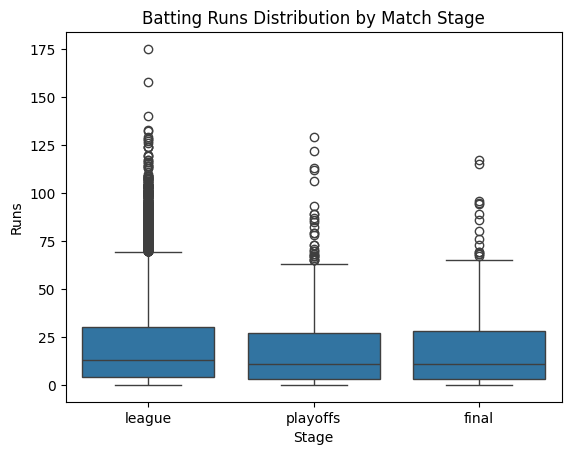

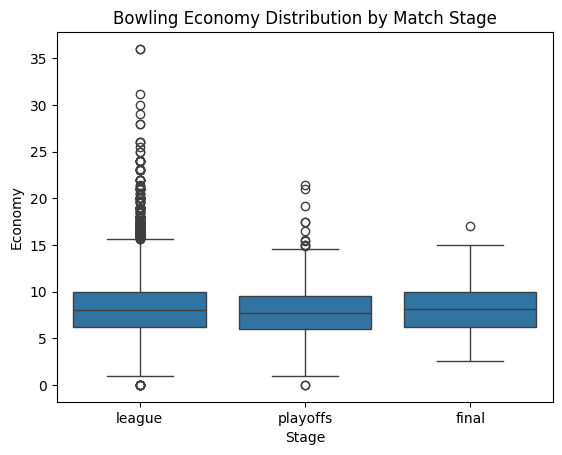

In [61]:
plt.figure()
sns.boxplot(data=bat_3, x="stage_bucket_3", y="runs", order=VALID_STAGES)
plt.title("Batting Runs Distribution by Match Stage")
plt.xlabel("Stage")
plt.ylabel("Runs")
plt.show()

plt.figure()
sns.boxplot(data=bowl_3, x="stage_bucket_3", y="economy", order=VALID_STAGES)
plt.title("Bowling Economy Distribution by Match Stage")
plt.xlabel("Stage")
plt.ylabel("Economy")
plt.show()

### Average Runs by Match Stage

This bar plot shows the mean number of runs scored per innings across league, playoffs, and final matches.

This helps evaluate whether overall batting performance differs under pressure.

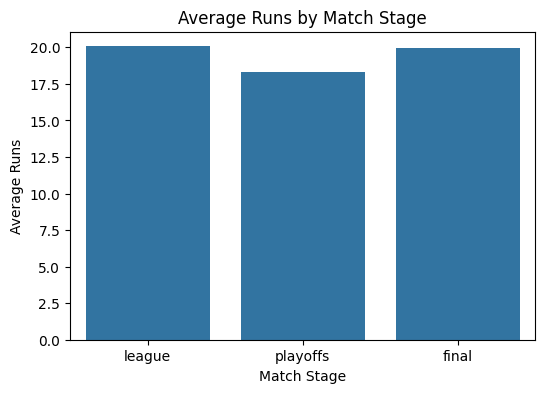

In [62]:
stage_order = ["league", "playoffs", "final"]

# Compute mean runs by stage
avg_runs_stage = (
    batting
    .groupby("stage_bucket")["runs"]
    .mean()
    .reindex(stage_order)
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(
    data=avg_runs_stage,
    x="stage_bucket",
    y="runs",
    order=stage_order
)

plt.title("Average Runs by Match Stage")
plt.xlabel("Match Stage")
plt.ylabel("Average Runs")
plt.show()

## Average Economy by Match Stage

This bar plot shows the mean economy rate conceded by bowlers across league, playoffs, and final matches.

This helps evaluate whether overall bowling performance differs under higher competitive pressure.

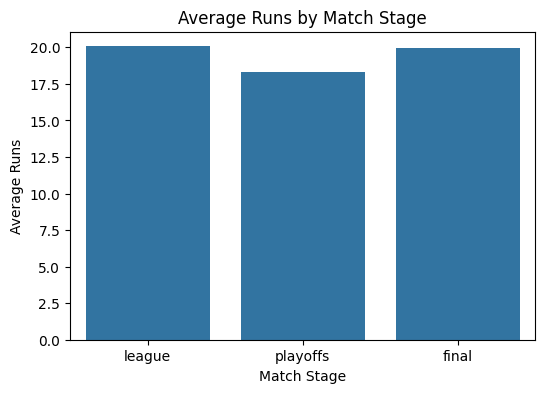

In [63]:

stage_order = ["league", "playoffs", "final"]

avg_runs_stage = (
    batting
    .groupby("stage_bucket")["runs"]
    .mean()
    .reindex(stage_order)
    .reset_index()
)

plt.figure(figsize=(6,4))
sns.barplot(data=avg_runs_stage, x="stage_bucket", y="runs")

plt.title("Average Runs by Match Stage")
plt.xlabel("Match Stage")
plt.ylabel("Average Runs")
plt.show()

## Top Players Most Affected Under Pressure (Playoffs + Finals)

We rank batters by a Pressure Impact Index (higher = worse under pressure) and visualize the top 50.
Bars are colored by the qualitative pressure label.

In [64]:
# Show all variables that look like batting tables
[v for v in globals().keys() if "bat" in v.lower()]

['batting',
 'bat_3',
 'dup_bat',
 'bat_summary_3',
 'bat_stage',
 'bat_wide',
 'batting_3stage_table',
 'batting_pressure_table']

In [65]:
batting_pressure_table = batting_3stage_table

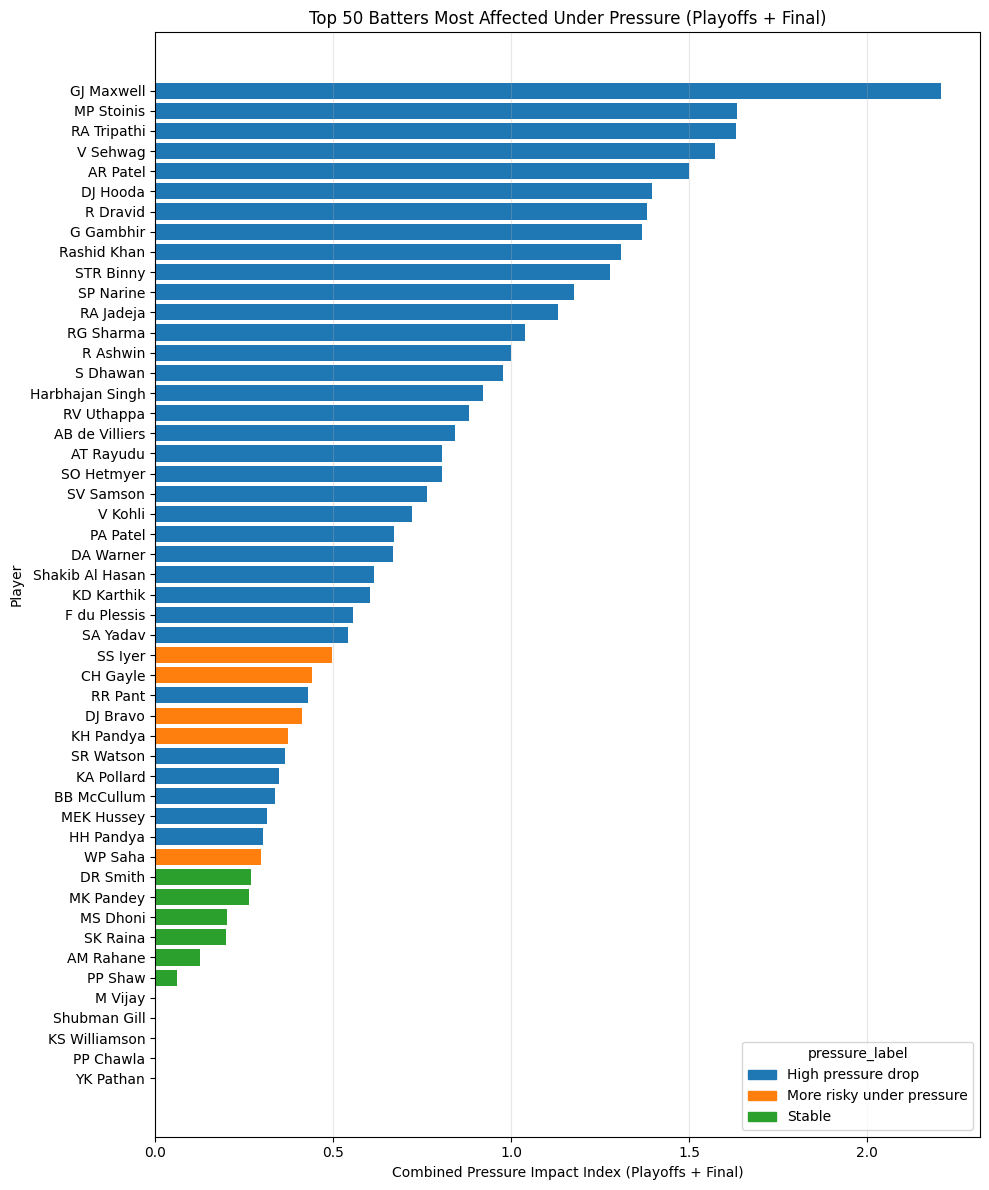

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df = batting_3stage_table.copy()

# --- Combine Playoffs + Final into a single "pressure" metric ---
df["pressure_impact_index"] = (
    df["playoffs_impact_index"].fillna(0) +
    df["final_impact_index"].fillna(0)
)

# Combine labels: prioritize "High pressure drop", then "More risky", else "Stable"
def combine_pressure_label(row):
    labels = {row.get("playoffs_label"), row.get("final_label")}
    if "High pressure drop" in labels:
        return "High pressure drop"
    if "More risky under pressure" in labels:
        return "More risky under pressure"
    return "Stable"

df["pressure_label"] = df.apply(combine_pressure_label, axis=1)

# --- Plot settings ---
PLAYER_COL = "player"
IMPACT_COL = "pressure_impact_index"
LABEL_COL  = "pressure_label"
TOP_N = 50

# Select top affected players
plot_df = df[[PLAYER_COL, IMPACT_COL, LABEL_COL]].dropna().copy()
top = plot_df.sort_values(IMPACT_COL, ascending=False).head(TOP_N).copy()
top = top.sort_values(IMPACT_COL, ascending=True)

# Color map (same vibe)
color_map = {
    "High pressure drop": "#1f77b4",        # blue
    "More risky under pressure": "#ff7f0e", # orange
    "Stable": "#2ca02c"                     # green
}
colors = top[LABEL_COL].map(color_map).fillna("#7f7f7f")

plt.figure(figsize=(10, 12))
plt.barh(top[PLAYER_COL], top[IMPACT_COL], color=colors)
plt.title("Top 50 Batters Most Affected Under Pressure (Playoffs + Final)")
plt.xlabel("Combined Pressure Impact Index (Playoffs + Final)")
plt.ylabel("Player")
plt.grid(axis="x", alpha=0.3)

legend_handles = [Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=legend_handles, title="pressure_label", loc="lower right")

plt.tight_layout()
plt.show()

## Top Players Most Affected Under Pressure (Playoffs + Finals)

We rank bowlers by a Pressure Impact Index (higher = worse under pressure) and visualize the top 50.
Bars are colored by the qualitative pressure label.

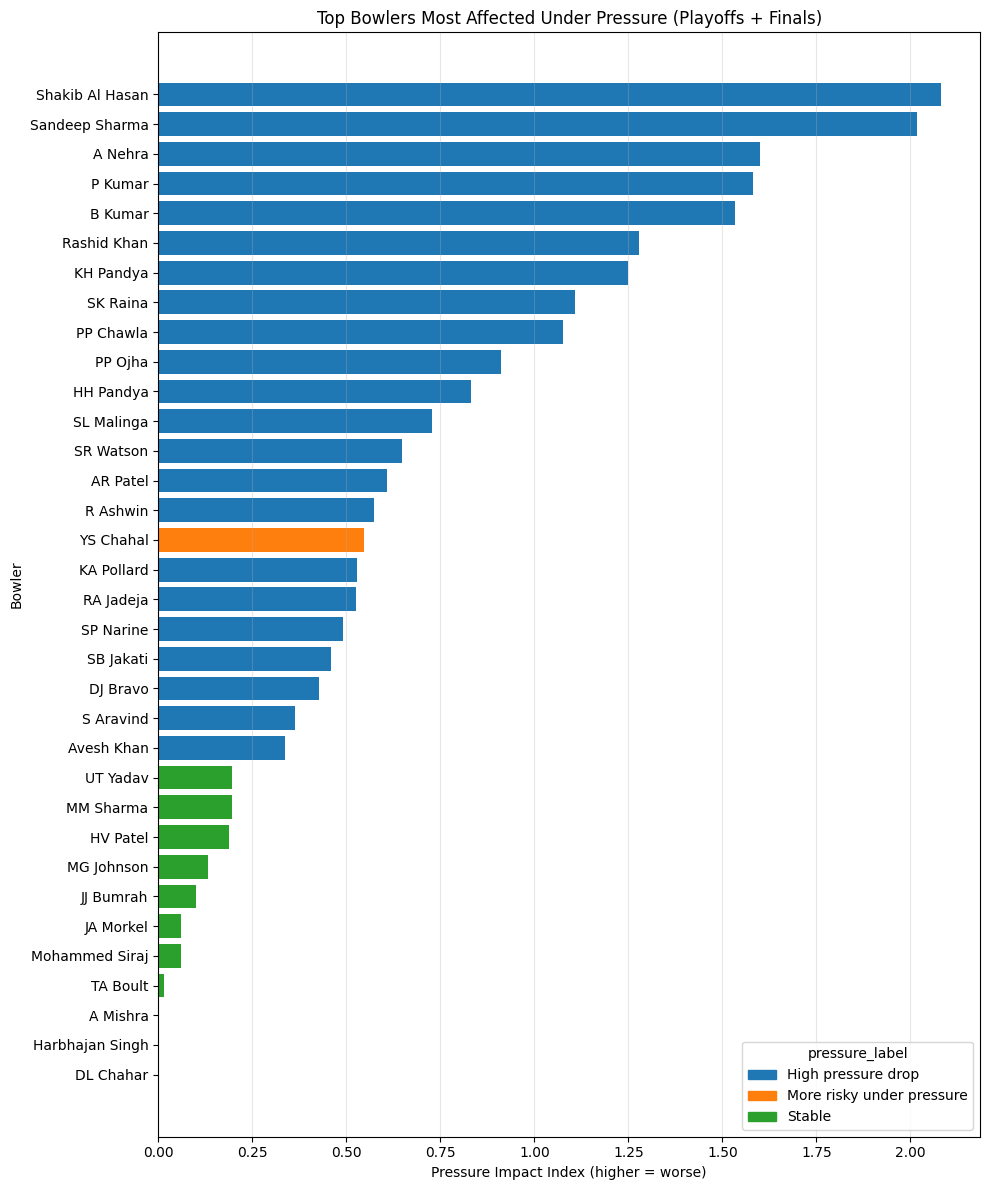

In [67]:
[v for v in globals().keys() if "bowl" in v.lower()]
['bowling',
 'bowl_3',
 'dup_bowl',
 'bowl_summary_3',
 'bowl_risk_rates',
 'bowl_stage',
 'bowl_wide',
 'bowling_3stage_table']

import numpy as np

df = bowling_3stage_table.copy()

# Combine playoffs + final into a single pressure index
df["pressure_impact_index"] = (
    df["playoffs_impact_index"].fillna(0) +
    df["final_impact_index"].fillna(0)
)

# Combine labels: prioritize High pressure drop > More risky > Stable
def combine_pressure_label(row):
    labels = {row.get("playoffs_label"), row.get("final_label")}
    if "High pressure drop" in labels:
        return "High pressure drop"
    if "More risky under pressure" in labels:
        return "More risky under pressure"
    return "Stable"

df["pressure_label"] = df.apply(combine_pressure_label, axis=1)

# Save as the table your plotting code expects
bowling_pressure_table = df

import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- expects bowling_pressure_table with these columns ---
# bowler, pressure_impact_index, pressure_label

BOWLER_COL = "bowler"
IMPACT_COL = "pressure_impact_index"
LABEL_COL  = "pressure_label"

TOP_N = 50

dfp = bowling_pressure_table[[BOWLER_COL, IMPACT_COL, LABEL_COL]].dropna().copy()

# Top N most affected
top = dfp.sort_values(IMPACT_COL, ascending=False).head(TOP_N).copy()

# Sort small->big so bars increase upward (nice visual)
top = top.sort_values(IMPACT_COL, ascending=True)

# Colors similar to your screenshot
color_map = {
    "High pressure drop": "#1f77b4",        # blue
    "More risky under pressure": "#ff7f0e", # orange
    "Stable": "#2ca02c"                     # green
}

colors = top[LABEL_COL].map(color_map).fillna("#7f7f7f")

plt.figure(figsize=(10, 12))
plt.barh(top[BOWLER_COL], top[IMPACT_COL], color=colors)

plt.title("Top Bowlers Most Affected Under Pressure (Playoffs + Finals)")
plt.xlabel("Pressure Impact Index (higher = worse)")
plt.ylabel("Bowler")
plt.grid(axis="x", alpha=0.3)

# Legend
handles = [Patch(color=v, label=k) for k, v in color_map.items()]
plt.legend(handles=handles, title="pressure_label", loc="lower right")

plt.tight_layout()
plt.show()